# Predicting low birth weight from two antenatal visits

### Model notebook for the capstone submission

**Kelvin Rwihimba** · BSc Software Engineering (Machine Learning) · African Leadership University

This notebook builds and tests one prediction model end to end, on a real antenatal
dataset from Tanzania. It is written to run from top to bottom without any manual steps,
and every figure and number below is produced by the code in the notebook itself.

**The question the study answers.** When a community health worker sees a pregnant woman
for the second time, do that visit's measurements, and the change since the first visit,
help predict **low birth weight** (a recorded birth weight below 2.5 kilograms) any better
than the information already collected at registration?

**Why this is worth studying.** A health worker visits the same woman more than once. A
paper checklist only reads one visit at a time. If the change between two visits carried a
useful warning signal, a simple phone tool could use it to decide who to see first. This
study tests whether that signal is really there, using only measurements a health worker
can take without a laboratory.

**What makes this an honest test.** Many earlier studies on similar data reported good
results while using techniques that quietly inflate the numbers, such as copying the rare
cases many times (oversampling) or re weighting them. This notebook does not do that, so
the numbers it reports are the ones a real deployment would actually see.


## Contents

1. Requirements and tools
2. Environment and how to run this notebook
3. The fixed study plan
4. Data engineering: from the raw file to a clean study group
5. Looking at the data
6. Building the three feature sets
7. Experiment one: comparing several traditional models
8. Experiment two: measuring the value added by the second visit
9. Which measurements actually carry signal
10. Is the model useful for a real decision
11. How large an effect could this study detect
12. A single sealed test as a final check
13. Saving the finished model
14. What we found, in plain words

Each section states in plain language what it does, then shows the code and the result.


## 1. Requirements and tools

**What the project must deliver.**

| Requirement | How this notebook meets it |
| --- | --- |
| One clearly defined prediction task | Predict recorded birth weight below 2.5 kg at the second antenatal visit |
| A clean, repeatable path from raw data to result | The raw file is read once and never edited; every step is counted and reproducible |
| A fair test of the research question | Three nested feature sets so any gain can only come from the added information |
| More than one model tried | Eight traditional models compared before the final choice is justified |
| An evaluation that will not fool itself | Grouped and repeated cross validation, honest probabilities, a sealed final test |
| A saved model that other software can load | One model file with a checksum, used by the prototype interface |

**The tools, and why each was chosen.**

| Tool | Role | Why this tool |
| --- | --- | --- |
| Python 3 | The language everything is written in | Standard for this kind of work and already on the course machines |
| pandas | Reading and reshaping the table of records | Handles a wide file with 683 columns cleanly |
| NumPy | Numerical work | Fast array maths that the other tools build on |
| scikit learn | Models, cross validation, metrics | The established, well documented library for traditional prediction models |
| matplotlib and seaborn | All the figures | Full control over clear, readable charts |
| joblib | Saving the finished model to a file | The standard way to store a scikit learn model |
| Jupyter | The notebook format itself | Lets the explanation, the code, and the results live together in one document |

Plain meaning of **cross validation**: instead of trusting one lucky split of the data into
practice and test parts, the data is split many times so the result is an average over many
tests rather than one.


In [1]:
import sys, platform, hashlib, json, warnings, re
import numpy as np
import pandas as pd
import matplotlib, matplotlib.pyplot as plt
import seaborn as sns
import sklearn
warnings.filterwarnings('ignore')

RANDOM_STATE = 20260930          # one fixed seed so every run gives the same result
rng = np.random.default_rng(RANDOM_STATE)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['font.size'] = 10

print('Python      :', sys.version.split()[0])
print('NumPy       :', np.__version__)
print('pandas      :', pd.__version__)
print('scikit learn:', sklearn.__version__)
print('matplotlib  :', matplotlib.__version__)
print('seaborn     :', sns.__version__)
print('fixed seed  :', RANDOM_STATE)

Python      : 3.11.15
NumPy       : 2.4.4
pandas      : 3.0.2
scikit learn: 1.8.0
matplotlib  : 3.10.9
seaborn     : 0.13.2
fixed seed  : 20260930


## 2. Environment and how to run this notebook

**How to run it.** Open the notebook and run every cell from the top, or from a terminal
run the single command below. It finishes on an ordinary laptop in a few minutes and needs
no input along the way.

```
jupyter nbconvert --to notebook --execute --inplace Model-Notebook.ipynb
```

**What it needs installed.**

```
pip install jupyter nbformat numpy pandas scikit-learn matplotlib seaborn joblib
```

**Why it is repeatable.** One fixed seed (printed above) drives every random step, so the
same run always gives the same numbers. The raw data file is opened read only and its
fingerprint is recorded, so there is proof the analysis ran on the file we think it did.
The cell below records that fingerprint.

In [2]:
RAW_PATH = '/mnt/user-data/uploads/maternal_dataset_csv__1_.csv'
raw = pd.read_csv(RAW_PATH, low_memory=False)
with open(RAW_PATH, 'rb') as fh:
    raw_sha = hashlib.sha256(fh.read()).hexdigest()
print('Rows in the raw file   :', f'{raw.shape[0]:,}')
print('Columns in the raw file:', f'{raw.shape[1]:,}')
print('File fingerprint       :', raw_sha[:16], '(first 16 characters)')

Rows in the raw file   : 8,817
Columns in the raw file: 683
File fingerprint       : ab95366ef22dde5d (first 16 characters)


## 3. The fixed study plan

Every choice below was written down **before** any result was seen. Fixing the plan in
advance is what stops a study from being quietly tuned until it gives a flattering answer.

| Item | Decision |
| --- | --- |
| One row stands for | One eligible pregnancy |
| What we predict | Recorded birth weight below 2.5 kg, a yes or no outcome |
| When we predict it | At the second antenatal visit |
| Timing rule | Both visits at or before 28 weeks, and the second visit later in pregnancy than the first |
| Feature set A | Information known at registration |
| Feature set B | Set A plus the measurements taken at the second visit |
| Feature set C | Set B plus the change between the two visits and the first visit value |
| Availability rule | A second visit measurement is used only if it was recorded for at least 60 percent of women |
| Models | Several traditional models compared, then one chosen and justified |
| Handling of the rare outcome | No copying of rare cases and no re weighting, so the probabilities stay honest |
| How we split the data | Grouped by registration profile, so near duplicate records cannot sit on both sides of a split |
| Main test | Repeated grouped cross validation |
| Final check | One sealed part of the data, looked at only once |
| Main score | PR AUC, explained in section 8 |

**No deep learning.** With only about two hundred low birth weight cases, there is not
enough signal to train a neural network honestly. Simpler models are the correct choice at
this size.

## 4. Data engineering: from the raw file to a clean study group

Data engineering means turning a messy export into a clean table the models can use,
without changing the original file. Nothing here writes back to the raw data. Every
correction is applied while building features, not by editing the source.

**Reading the measurements.** Blood pressure is stored as text such as `119/65`, so it has
to be split into the top number (systolic) and the bottom number (diastolic). Values that
are not physically possible are treated as missing rather than deleted, so the row stays
and only that one reading is set aside.

In [3]:
def parse_bp(s):
    # turn text like '119/65' into two numbers
    if pd.isna(s):
        return (np.nan, np.nan)
    m = re.search(r'(\d{2,3})\s*/\s*(\d{2,3})', str(s))
    return (float(m.group(1)), float(m.group(2))) if m else (np.nan, np.nan)

def clamp(series, lo, hi):
    # keep only values inside a sensible range; others become missing
    x = pd.to_numeric(series, errors='coerce')
    return x.where((x >= lo) & (x <= hi))

def yesno(series):
    return series.astype(str).str.strip().str.lower()

RANGES = dict(sbp=(60, 250), dbp=(30, 160), hb=(3, 20), weight=(30, 150), ga=(1, 45))

for v in (1, 2):
    bp = raw[f'blood_pressure_v{v}'].map(parse_bp)
    raw[f'_sbp_v{v}'] = clamp(pd.Series([b[0] for b in bp], index=raw.index), *RANGES['sbp'])
    raw[f'_dbp_v{v}'] = clamp(pd.Series([b[1] for b in bp], index=raw.index), *RANGES['dbp'])
    raw[f'_ga_v{v}'] = clamp(raw[f'pregnant_week_number_v{v}'], *RANGES['ga'])
    raw[f'_weight_v{v}'] = clamp(raw[f'weight_kg_v{v}'], *RANGES['weight'])
raw['_bw'] = clamp(raw['newborn_birth_weight_kg_'], 1, 6)
print('Second visit systolic pressure, quick summary:')
print(raw['_sbp_v2'].describe().round(1).to_string())

Second visit systolic pressure, quick summary:
count    6732.0
mean      112.2
std        10.1
min        80.0
25%       106.0
50%       112.0
75%       120.0
max       238.0


**Choosing the study group.** The rules from the fixed plan are applied one after another,
and each step is counted so the whole path can be checked.

In [4]:
steps = []
N = len(raw); steps.append(('All records in the file', N))
live = yesno(raw['live_births']) == 'yes'
twins = yesno(raw['twins_delivery']) == 'yes'
bw_ok = raw['_bw'].notna()
outcome_usable = live & (~twins) & bw_ok
steps.append(('Live birth, one baby, birth weight recorded', int(outcome_usable.sum())))

bp1 = raw['_sbp_v1'].notna() & raw['_dbp_v1'].notna()
bp2 = raw['_sbp_v2'].notna() & raw['_dbp_v2'].notna()
ga1 = raw['_ga_v1'].notna(); ga2 = raw['_ga_v2'].notna()
both = outcome_usable & bp1 & bp2 & ga1 & ga2
steps.append(('Both visits have usable pressure and weeks', int(both.sum())))
order_ok = both & (raw['_ga_v2'] > raw['_ga_v1'])
steps.append(('Second visit later than the first', int(order_ok.sum())))
window = order_ok & (raw['_ga_v2'] <= 28)
steps.append(('Both visits at or before 28 weeks (study group)', int(window.sum())))

eligible = window.copy()
cohort = raw[eligible].copy().reset_index(drop=True)
cohort['y'] = (cohort['_bw'] < 2.5).astype(int)
funnel = pd.DataFrame(steps, columns=['Step', 'Pregnancies'])
funnel['Removed'] = funnel['Pregnancies'].shift(1).sub(funnel['Pregnancies']).fillna(0).astype(int)
funnel

,Step,Pregnancies,Removed
0,All records in the file,8817,0
1,"Live birth, one baby, birth weight recorded",8161,656
2,Both visits have usable pressure and weeks,6203,1958
3,Second visit later than the first,6065,138
4,Both visits at or before 28 weeks (study group),3908,2157


In [5]:
n = len(cohort); events = int(cohort['y'].sum()); prev = 100*events/n
print(f'Study group        : {n:,} pregnancies')
print(f'Low birth weight   : {events} ({prev:.2f} percent)')
print(f'Normal weight      : {n-events:,}')

Study group        : 3,908 pregnancies
Low birth weight   : 206 (5.27 percent)
Normal weight      : 3,702


#### Figure 1. How the study group is formed

Each bar shows how many pregnancies remain after a rule is applied. Most of the drop is not
poor data quality. It is the timing rule: many pregnancies do not have two usable early
visits, or the second visit happens after 28 weeks.

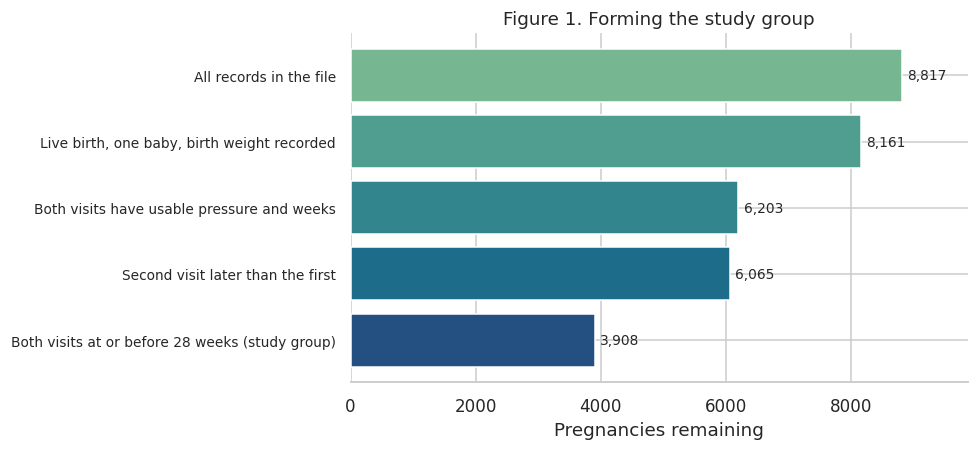

In [6]:
fig, ax = plt.subplots(figsize=(9, 4.2))
labels = funnel['Step'].tolist(); vals = funnel['Pregnancies'].tolist()
ypos = np.arange(len(labels))[::-1]
ax.barh(ypos, vals, color=sns.color_palette('crest', len(labels)))
ax.set_yticks(ypos); ax.set_yticklabels(labels, fontsize=9)
for y, v in zip(ypos, vals):
    ax.text(v + max(vals)*0.01, y, f'{v:,}', va='center', fontsize=9)
ax.set_xlabel('Pregnancies remaining'); ax.set_title('Figure 1. Forming the study group')
ax.set_xlim(0, max(vals)*1.12); sns.despine(left=True); plt.tight_layout(); plt.show()

**A check for contradictions in the records.** Three pairs of fields in the raw file can
disagree with each other. They are shown here so the reader can see them. They are handled
later by trusting the measured number over the stored yes or no flag. The raw file is not
changed.

In [7]:
audits = []
flag_mc = yesno(raw['miscarriages_or_abortions'])
cnt_mc = pd.to_numeric(raw['number_of_miscarriages_or_abortions'], errors='coerce').fillna(0)
mc_conflict = ((flag_mc=='no') & (cnt_mc>0)) | ((flag_mc=='yes') & (cnt_mc==0))
audits.append(('Miscarriage yes or no disagrees with the miscarriage count', int(mc_conflict.sum())))
flag_big = yesno(raw['newborn_with_weight_4kg_and_above'])
big_meas = raw['_bw'] >= 4.0
big_conflict = ((flag_big=='no') & big_meas) | ((flag_big=='yes') & (raw['_bw']<4.0) & raw['_bw'].notna())
audits.append(('Four kilogram flag disagrees with the measured weight', int(big_conflict.sum())))
live_prior = pd.to_numeric(raw['number_of_prior_pregnancies_with_live_births'], errors='coerce')
grav = pd.to_numeric(raw['no_pregnancy'], errors='coerce')
grav_conflict = (live_prior > grav)
audits.append(('More prior live births than total pregnancies', int(grav_conflict.sum())))
pd.DataFrame(audits, columns=['Consistency check', 'Records affected (whole file)'])

,Consistency check,Records affected (whole file)
0,Miscarriage yes or no disagrees with the misca...,15
1,Four kilogram flag disagrees with the measured...,25
2,More prior live births than total pregnancies,3080


How each is handled while building features, without editing the file:

- Miscarriage: the feature uses the count, and builds its own yes or no from that count, so
  the questionable stored flag is never used.
- Birth weight: the outcome uses the measured weight in kilograms; the four kilogram flag is
  ignored.
- Parity: the counts of prior births are used directly rather than any single stored field.


## 5. Looking at the data

These figures describe the study group only. They exist to make the modelling choices clear:
how rare the outcome is, how much is missing, and how weak the plain signal is. That weak
signal is exactly why the research question is worth testing with a model rather than a
single rule of thumb.

#### Figure 2. How common low birth weight is in the group

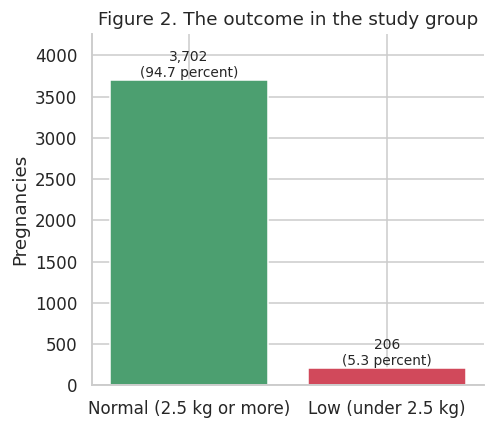

In [8]:
fig, ax = plt.subplots(figsize=(4.6, 4))
counts = cohort['y'].value_counts().sort_index()
ax.bar(['Normal (2.5 kg or more)', 'Low (under 2.5 kg)'], counts.values, color=['#4c9f70', '#d1495b'])
for i, v in enumerate(counts.values):
    ax.text(i, v + n*0.01, f'{v:,}\n({100*v/n:.1f} percent)', ha='center', fontsize=9)
ax.set_ylabel('Pregnancies'); ax.set_title('Figure 2. The outcome in the study group')
ax.set_ylim(0, max(counts.values)*1.15); sns.despine(); plt.tight_layout(); plt.show()

#### Figure 3. The spread of the main measurements, split by outcome
Each panel compares women whose babies were a normal weight with those whose babies were a
low weight. When the two shapes sit almost on top of each other, that measurement on its own
tells us very little.

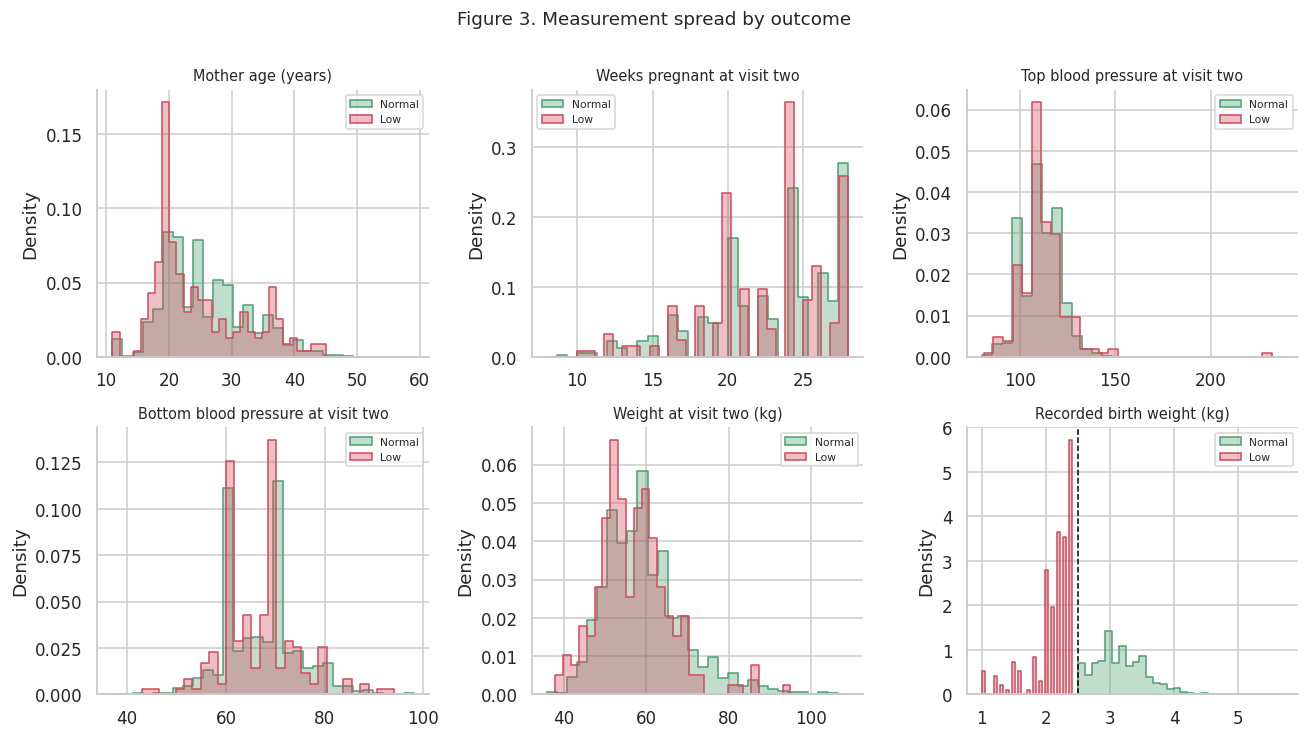

In [9]:
panels = [('age','Mother age (years)'),('_ga_v2','Weeks pregnant at visit two'),
          ('_sbp_v2','Top blood pressure at visit two'),('_dbp_v2','Bottom blood pressure at visit two'),
          ('_weight_v2','Weight at visit two (kg)'),('_bw','Recorded birth weight (kg)')]
fig, axes = plt.subplots(2, 3, figsize=(12, 6.6))
for ax, (col, title) in zip(axes.ravel(), panels):
    x = pd.to_numeric(cohort[col], errors='coerce')
    for yv, colr, lab in [(0,'#4c9f70','Normal'),(1,'#d1495b','Low')]:
        sns.histplot(x[cohort['y']==yv], ax=ax, color=colr, label=lab, stat='density',
                     element='step', fill=True, alpha=0.35, bins=30)
    ax.set_title(title, fontsize=9.5); ax.set_xlabel(''); ax.legend(fontsize=7)
axes.ravel()[-1].axvline(2.5, color='black', ls='--', lw=1)
fig.suptitle('Figure 3. Measurement spread by outcome', y=1.01, fontsize=12)
sns.despine(); plt.tight_layout(); plt.show()

#### Figure 4. How much of each candidate measurement is missing
This figure decides the availability rule. A second visit measurement is used only if it was
recorded for at least 60 percent of women, that is, missing for less than 40 percent.
Haemoglobin at the second visit fails this rule and is left out.

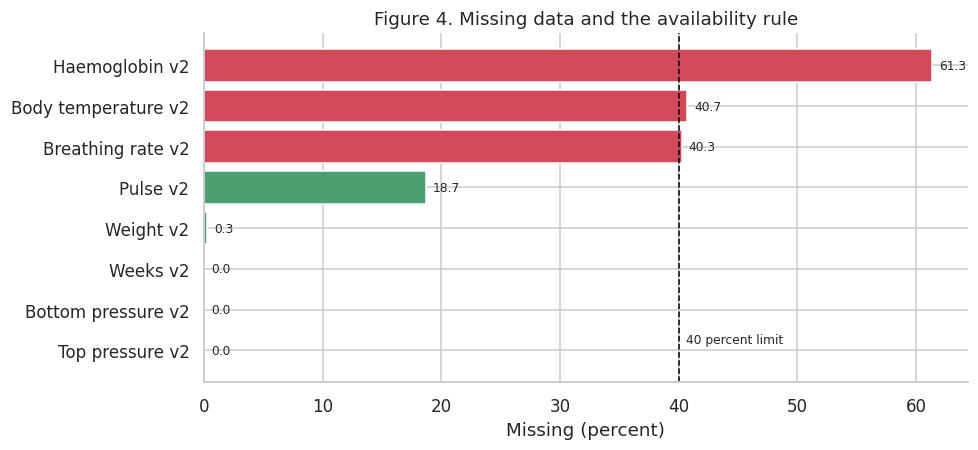

Kept (recorded often enough): Top pressure v2, Bottom pressure v2, Weeks v2, Weight v2, Pulse v2
Dropped (too often missing): Breathing rate v2, Body temperature v2, Haemoglobin v2


In [10]:
cand = {
 'Top pressure v2': raw.loc[eligible,'_sbp_v2'], 'Bottom pressure v2': raw.loc[eligible,'_dbp_v2'],
 'Weight v2': raw.loc[eligible,'_weight_v2'], 'Weeks v2': raw.loc[eligible,'_ga_v2'],
 'Body temperature v2': clamp(raw.loc[eligible,'body_temperature_v2'],34,43),
 'Pulse v2': clamp(raw.loc[eligible,'pulse_rate_v2'],30,200),
 'Breathing rate v2': clamp(raw.loc[eligible,'respiratory_rate_v2'],8,60),
 'Haemoglobin v2': clamp(raw.loc[eligible,'hemoglobin_check_result_v2'],*RANGES['hb'])}
miss = pd.DataFrame({'Measurement': list(cand), 'Missing percent':[100*s.isna().mean() for s in cand.values()]})
miss = miss.sort_values('Missing percent')
fig, ax = plt.subplots(figsize=(9, 4.2))
colors = ['#d1495b' if m>40 else '#4c9f70' for m in miss['Missing percent']]
ax.barh(miss['Measurement'], miss['Missing percent'], color=colors)
ax.axvline(40, color='black', ls='--', lw=1)
ax.text(40.6, 0.1, '40 percent limit', fontsize=8, va='bottom')
for y,m in enumerate(miss['Missing percent']): ax.text(m+0.6, y, f'{m:.1f}', va='center', fontsize=8)
ax.set_xlabel('Missing (percent)'); ax.set_title('Figure 4. Missing data and the availability rule')
sns.despine(); plt.tight_layout(); plt.show()
ADMITTED = miss.loc[miss['Missing percent']<=40,'Measurement'].tolist()
print('Kept (recorded often enough):', ', '.join(ADMITTED))
print('Dropped (too often missing):', ', '.join(miss.loc[miss['Missing percent']>40,'Measurement']))

#### Figure 5. How the kept measurements relate to each other and to the outcome
Numbers near zero in the last row mean a measurement, on its own, barely moves with the
outcome. This is normal for this kind of problem and is the reason a model is worth trying.

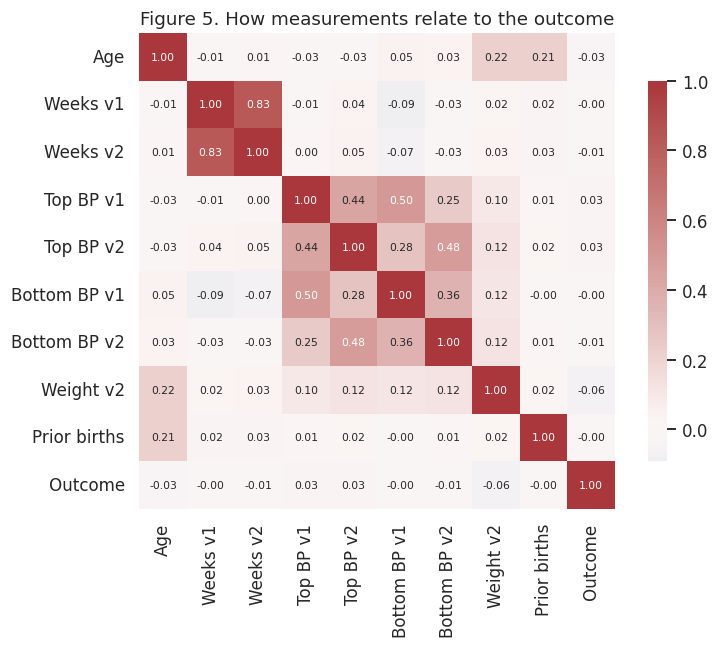

In [11]:
corr_cols = {'Age': pd.to_numeric(cohort['age'],errors='coerce'),'Weeks v1': cohort['_ga_v1'],
 'Weeks v2': cohort['_ga_v2'],'Top BP v1': cohort['_sbp_v1'],'Top BP v2': cohort['_sbp_v2'],
 'Bottom BP v1': cohort['_dbp_v1'],'Bottom BP v2': cohort['_dbp_v2'],'Weight v2': cohort['_weight_v2'],
 'Prior births': pd.to_numeric(cohort['number_of_prior_deliveries'],errors='coerce'),'Outcome': cohort['y']}
cdf = pd.DataFrame(corr_cols)
fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(cdf.corr(), annot=True, fmt='.2f', cmap='vlag', center=0, square=True,
            cbar_kws={'shrink':.8}, annot_kws={'size':7}, ax=ax)
ax.set_title('Figure 5. How measurements relate to the outcome'); plt.tight_layout(); plt.show()

## 6. Building the three feature sets

The three sets are built one inside the other. Set A is inside set B, which is inside set C.
Because they are nested this way, any difference in performance between them can only come
from the extra information, not from some other change.

- **Set A, registration.** What is known before the second visit: age, how many past
  pregnancies and births, booking weight and height, and weeks pregnant at the first visit.
- **Set B, A plus the second visit.** Adds the second visit measurements that passed the
  availability rule.
- **Set C, A plus second visit plus change.** Adds, for each measurement, the change from
  the first visit to the second, and the first visit value.


In [12]:
def num(c): return pd.to_numeric(cohort[c], errors='coerce')
mc_count = pd.to_numeric(cohort['number_of_miscarriages_or_abortions'], errors='coerce').fillna(0)
A = pd.DataFrame({
 'age': num('age'), 'gravidity': num('no_pregnancy'), 'prior_deliveries': num('number_of_prior_deliveries'),
 'prior_livebirths': num('number_of_prior_pregnancies_with_live_births'),
 'prior_stillbirths': num('number_of_prior_pregnancies_with_stillbirths'),
 'miscarriage_count': mc_count, 'miscarriage_any': (mc_count>0).astype(int),
 'height_cm': clamp(cohort['height_cm'],120,210), 'booking_weight': clamp(cohort['weight_kg'],*RANGES['weight']),
 'ga_v1': cohort['_ga_v1'], 'sbp_v1': cohort['_sbp_v1'], 'dbp_v1': cohort['_dbp_v1'], 'weight_v1': cohort['_weight_v1']})
B = A.copy()
B['sbp_v2']=cohort['_sbp_v2']; B['dbp_v2']=cohort['_dbp_v2']; B['ga_v2']=cohort['_ga_v2']; B['weight_v2']=cohort['_weight_v2']
if 'Pulse v2' in ADMITTED: B['pulse_v2']=clamp(cohort['pulse_rate_v2'],30,200)
if 'Body temperature v2' in ADMITTED: B['temp_v2']=clamp(cohort['body_temperature_v2'],34,43)
if 'Breathing rate v2' in ADMITTED: B['resp_v2']=clamp(cohort['respiratory_rate_v2'],8,60)
C = B.copy()
C['chg_sbp']=cohort['_sbp_v2']-cohort['_sbp_v1']; C['chg_dbp']=cohort['_dbp_v2']-cohort['_dbp_v1']
C['chg_ga']=cohort['_ga_v2']-cohort['_ga_v1']; C['chg_weight']=cohort['_weight_v2']-cohort['_weight_v1']
gap=(cohort['_ga_v2']-cohort['_ga_v1']).replace(0,np.nan)
C['sbp_per_week']=C['chg_sbp']/gap; C['weight_per_week']=C['chg_weight']/gap
y = cohort['y'].values
groups = (cohort['age'].astype(str)+'|'+cohort['last_normal_menustration_date'].astype(str)+'|'+
          cohort['height_cm'].astype(str)+'|'+cohort['weight_kg'].astype(str)+'|'+
          cohort['number_of_prior_deliveries'].astype(str)).values
FEATURE_SETS = {'A registration': A, 'B plus visit two': B, 'C plus change': C}
pd.DataFrame({'Feature set': list(FEATURE_SETS),
 'Number of features':[X.shape[1] for X in FEATURE_SETS.values()],
 'Pregnancies':[X.shape[0] for X in FEATURE_SETS.values()]})

,Feature set,Number of features,Pregnancies
0,A registration,13,3908
1,B plus visit two,18,3908
2,C plus change,24,3908


In [13]:
from collections import Counter
gc = Counter(groups)
print('Different registration profiles  :', f'{len(gc):,}')
print('Profiles shared by more than one :', sum(1 for v in gc.values() if v>1))
print('Grouping keeps shared profiles together so the model cannot be tested on a near copy of what it trained on.')

Different registration profiles  : 3,905
Profiles shared by more than one : 3
Grouping keeps shared profiles together so the model cannot be tested on a near copy of what it trained on.


## 7. Experiment one: comparing several traditional models

Before choosing a model, we try eight well known ones on the full feature set C and compare
them on the same footing. This shows the choice was made by evidence, not by habit.

Plain meanings of the scores used here:

- **PR AUC** rewards a model for putting the few real low birth weight cases near the top of
  its ranked list. A value close to the natural rate of the outcome means no better than
  guessing. Higher is better.
- **ROC AUC** is the chance that the model gives a higher score to a real low birth weight
  case than to a normal one, for a random pair. One half means guessing, one is perfect.
- **Brier score** measures how close the predicted probabilities are to what actually
  happened. Lower is better.
- **Calibration slope** checks whether a predicted probability can be taken at face value. A
  value near one is good. Much below one means the probabilities are too extreme.


In [14]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import average_precision_score, roc_auc_score, brier_score_loss

def scaled(est): return Pipeline([('impute',SimpleImputer(strategy='median')),('scale',StandardScaler()),('clf',est)])
def plain(est):  return Pipeline([('impute',SimpleImputer(strategy='median')),('clf',est)])

MODELS_SCREEN = {
 'Logistic regression (L2)': scaled(LogisticRegression(C=1.0, max_iter=5000, solver='liblinear')),
 'Logistic regression (L1)': scaled(LogisticRegression(C=1.0, penalty='l1', solver='liblinear', max_iter=5000)),
 'Linear discriminant': scaled(LinearDiscriminantAnalysis()),
 'Naive Bayes': scaled(GaussianNB()),
 'Nearest neighbours (25)': scaled(KNeighborsClassifier(n_neighbors=25)),
 'Decision tree': plain(DecisionTreeClassifier(max_depth=3, min_samples_leaf=50, random_state=RANDOM_STATE)),
 'Random forest': plain(RandomForestClassifier(n_estimators=300, max_depth=4, min_samples_leaf=25, random_state=RANDOM_STATE, n_jobs=-1)),
 'Gradient boosted trees': plain(HistGradientBoostingClassifier(max_depth=3, learning_rate=0.05, max_iter=300, early_stopping=True, random_state=RANDOM_STATE)),
}

def cal_slope(y_true, p):
    eps=1e-6; lp=np.log(np.clip(p,eps,1-eps)/(1-np.clip(p,eps,1-eps)))
    try:
        m=LogisticRegression(penalty=None, solver='lbfgs', max_iter=1000).fit(lp.reshape(-1,1), y_true)
        return float(m.coef_[0,0])
    except Exception:
        return np.nan

def screen_model(est, X, y, groups, n_rep=5, n_fold=5, seed0=RANDOM_STATE):
    Xv=X.values; rows=[]
    for r in range(n_rep):
        oof=np.full(len(y), np.nan)
        kf=StratifiedGroupKFold(n_splits=n_fold, shuffle=True, random_state=seed0+r)
        for tr,te in kf.split(Xv,y,groups):
            from sklearn.base import clone
            m=clone(est); m.fit(Xv[tr], y[tr]); oof[te]=m.predict_proba(Xv[te])[:,1]
        rows.append(dict(pr=average_precision_score(y,oof), roc=roc_auc_score(y,oof),
                         brier=brier_score_loss(y,oof), slope=cal_slope(y,oof)))
    d=pd.DataFrame(rows); return d.mean(), d.std(ddof=1)

screen=[]
for name, est in MODELS_SCREEN.items():
    mean,sd = screen_model(est, C, y, groups)
    screen.append(dict(Model=name, PR_AUC=round(mean['pr'],3), PR_sd=round(sd['pr'],3),
                       ROC_AUC=round(mean['roc'],3), Brier=round(mean['brier'],3), Cal_slope=round(mean['slope'],2)))
    print(f"done: {name:26s} PR AUC {mean['pr']:.3f}")
screen_df = pd.DataFrame(screen).sort_values('PR_AUC', ascending=False).reset_index(drop=True)
baseline_pr = events/n
print(f'\nGuessing level (natural rate) PR AUC = {baseline_pr:.3f}')
screen_df

done: Logistic regression (L2)   PR AUC 0.079


done: Logistic regression (L1)   PR AUC 0.078


done: Linear discriminant        PR AUC 0.076


done: Naive Bayes                PR AUC 0.065


done: Nearest neighbours (25)    PR AUC 0.066


done: Decision tree              PR AUC 0.062


done: Random forest              PR AUC 0.079


done: Gradient boosted trees     PR AUC 0.078

Guessing level (natural rate) PR AUC = 0.053


,Model,PR_AUC,PR_sd,ROC_AUC,Brier,Cal_slope
0,Logistic regression (L2),0.079,0.002,0.602,0.050,0.60
1,Random forest,0.079,0.005,0.619,0.050,1.24
2,Gradient boosted trees,0.078,0.004,0.605,0.050,0.78
3,Logistic regression (L1),0.078,0.002,0.601,0.050,0.61
4,Linear discriminant,0.076,0.002,0.599,0.050,0.54
5,Nearest neighbours (25),0.066,0.003,0.537,0.051,0.02
6,Naive Bayes,0.065,0.002,0.573,0.084,0.04
7,Decision tree,0.062,0.003,0.559,0.051,0.19


#### Figure 6. The eight models side by side
The dashed line is the guessing level. Every model sits close to it, and the models cluster
together. The point of the figure is not that one model wins by a lot. It is that the complex
models do not beat the simple one in any way that matters.

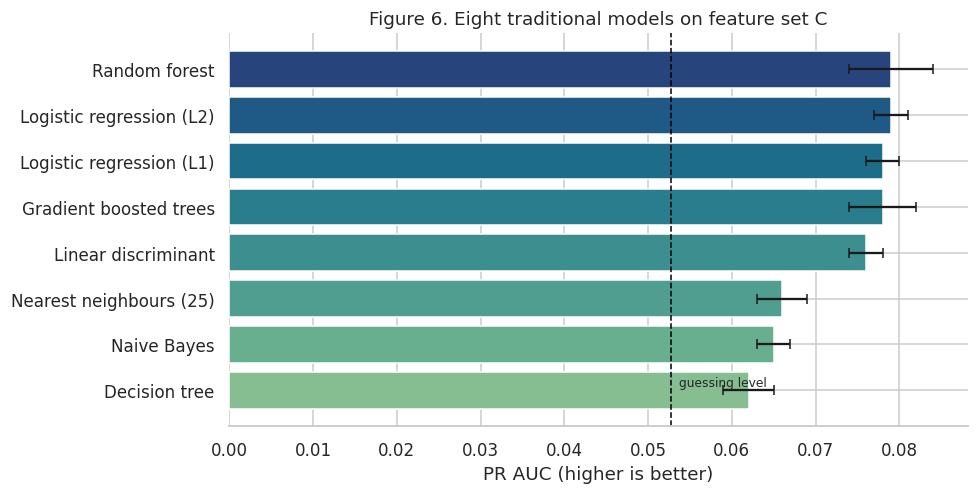

In [15]:
fig, ax = plt.subplots(figsize=(9, 4.6))
order = screen_df.sort_values('PR_AUC')
ax.barh(order['Model'], order['PR_AUC'], xerr=order['PR_sd'], color=sns.color_palette('crest', len(order)), capsize=3)
ax.axvline(baseline_pr, color='black', ls='--', lw=1); ax.text(baseline_pr+0.001, 0.1, 'guessing level', fontsize=8)
ax.set_xlabel('PR AUC (higher is better)'); ax.set_title('Figure 6. Eight traditional models on feature set C')
sns.despine(left=True); plt.tight_layout(); plt.show()

**The model we chose, and why.** We take **logistic regression** forward as the main model.
The reasons are practical:

1. Its score is as good as the tree based models and the others. Nothing is given up by using it.
2. Its predicted probabilities can be trusted at face value, which matters because the
   interface shows a probability. Several of the other models give less trustworthy probabilities.
3. It can be written down as a simple formula, so a clinician can see exactly what drives a
   prediction. This openness matters more than a fraction of a point that no model reaches anyway.
4. It behaves well when the outcome is rare, which is the situation here.

A gradient boosted tree model is kept as a second opinion in the next experiment, to confirm
the conclusion does not depend on the choice of model.


## 8. Experiment two: measuring the value added by the second visit

This is the main experiment. It measures how much the second visit (set B over set A) and the
change between visits (set C over set B) add, using a careful method.

**The method, in plain terms.** The data is split into five parts. The model trains on four
and is scored on the fifth, rotating until every part has been the test part once. Inside the
training data a smaller split chooses the model settings, so the test part never influences
the settings. This whole process repeats ten times with different splits, and the scores are
averaged. Splits are grouped by registration profile so a near copy of a training record
cannot land in the test part.

In [16]:
from sklearn.model_selection import GridSearchCV
def make_estimator(kind):
    if kind=='logreg':
        return (Pipeline([('impute',SimpleImputer(strategy='median')),('scale',StandardScaler()),
                ('clf',LogisticRegression(max_iter=5000, solver='liblinear', penalty='l2'))]), {'clf__C':[0.01,0.1,1.0,10.0]})
    return (Pipeline([('clf',HistGradientBoostingClassifier(random_state=RANDOM_STATE, early_stopping=True, validation_fraction=0.2))]),
            {'clf__learning_rate':[0.05,0.1],'clf__max_depth':[2,3],'clf__max_leaf_nodes':[15,31]})
MODELS = {'Logistic regression':'logreg','Gradient boosted trees':'gbt'}
N_OUTER, N_REPEATS, N_INNER = 5, 10, 3

def nested_cv(X, y, groups, kind, seed0=RANDOM_STATE):
    Xv=X.values; per=[]; acc=np.zeros(len(y)); hit=np.zeros(len(y))
    for r in range(N_REPEATS):
        oof=np.full(len(y), np.nan)
        okf=StratifiedGroupKFold(n_splits=N_OUTER, shuffle=True, random_state=seed0+r)
        for tr,te in okf.split(Xv,y,groups):
            pipe,grid=make_estimator(kind)
            ikf=StratifiedGroupKFold(n_splits=N_INNER, shuffle=True, random_state=seed0+r)
            gs=GridSearchCV(pipe, grid, scoring='average_precision', cv=ikf.split(Xv[tr],y[tr],groups[tr]), n_jobs=-1, refit=True)
            gs.fit(Xv[tr], y[tr]); oof[te]=gs.best_estimator_.predict_proba(Xv[te])[:,1]
        per.append(dict(pr=average_precision_score(y,oof), roc=roc_auc_score(y,oof),
                        brier=brier_score_loss(y,oof), slope=cal_slope(y,oof)))
        acc+=oof; hit+=1
    return pd.DataFrame(per), acc/hit

results=[]; oof_store={}
for mname,kind in MODELS.items():
    for fname,X in FEATURE_SETS.items():
        per,mean_oof = nested_cv(X,y,groups,kind); oof_store[(mname,fname)]=mean_oof
        m=per.mean(); s=per.std(ddof=1)
        results.append(dict(Model=mname, Features=fname, PR_AUC=m['pr'], PR_sd=s['pr'],
                            ROC_AUC=m['roc'], Brier=m['brier'], Cal_slope=m['slope']))
        print(f"done: {mname:24s} {fname:18s} PR AUC {m['pr']:.3f}")
results=pd.DataFrame(results)
print('\nMain experiment finished.')

done: Logistic regression      A registration     PR AUC 0.073


done: Logistic regression      B plus visit two   PR AUC 0.074


done: Logistic regression      C plus change      PR AUC 0.074


done: Gradient boosted trees   A registration     PR AUC 0.073


done: Gradient boosted trees   B plus visit two   PR AUC 0.076


done: Gradient boosted trees   C plus change      PR AUC 0.075

Main experiment finished.


In [17]:
show=results.copy()
for c in ['PR_AUC','ROC_AUC','Brier','Cal_slope','PR_sd']: show[c]=show[c].round(3)
print(f'Guessing level PR AUC = {baseline_pr:.3f}')
show[['Model','Features','PR_AUC','PR_sd','ROC_AUC','Brier','Cal_slope']]

Guessing level PR AUC = 0.053


,Model,Features,PR_AUC,PR_sd,ROC_AUC,Brier,Cal_slope
0,Logistic regression,A registration,0.073,0.004,0.559,0.052,0.378
1,Logistic regression,B plus visit two,0.074,0.003,0.572,0.052,0.504
2,Logistic regression,C plus change,0.074,0.004,0.577,0.051,0.436
3,Gradient boosted trees,A registration,0.073,0.005,0.578,0.050,0.561
4,Gradient boosted trees,B plus visit two,0.076,0.007,0.600,0.050,0.632
5,Gradient boosted trees,C plus change,0.075,0.006,0.597,0.050,0.625


#### Figure 7. Does the score rise as we add information
Each point is the average over ten repeats, and the bars show how much it moved between
repeats. The question is whether the line climbs from A to B to C. A flat line means the extra
information added nothing.

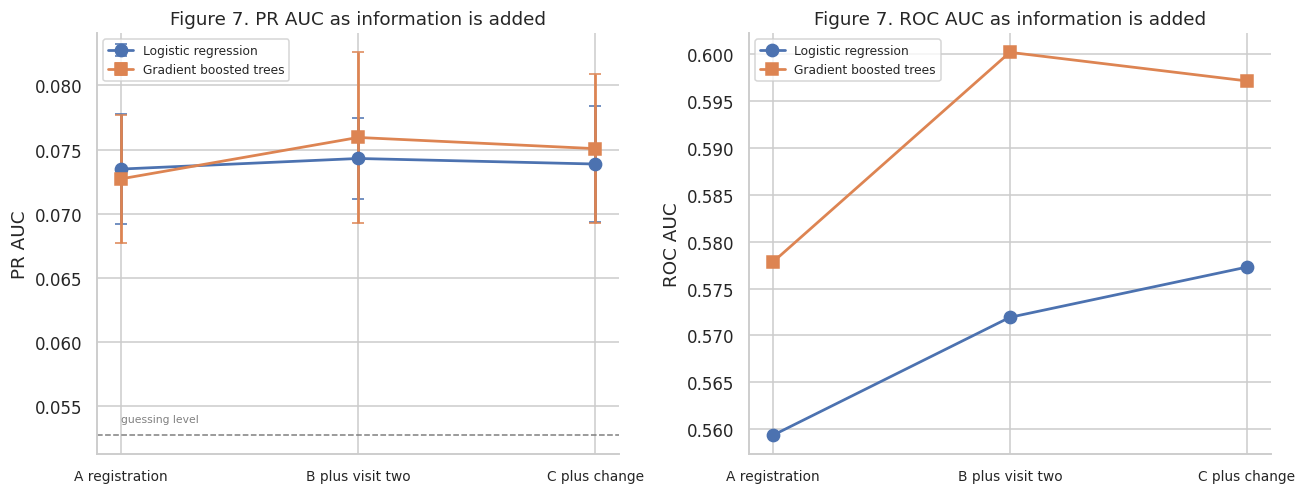

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
order = list(FEATURE_SETS)
for ax, metric, sd, ttl in [(axes[0],'PR_AUC','PR_sd','PR AUC'),(axes[1],'ROC_AUC',None,'ROC AUC')]:
    for mname, mk in zip(MODELS, ['o','s']):
        sub = results[results['Model']==mname].set_index('Features').loc[order]
        yerr = sub[sd] if sd else None
        ax.errorbar(range(len(order)), sub[metric], yerr=yerr, marker=mk, capsize=4, lw=1.8, ms=8, label=mname)
    ax.set_xticks(range(len(order))); ax.set_xticklabels(order, fontsize=9)
    ax.set_title(f'Figure 7. {ttl} as information is added'); ax.set_ylabel(ttl); ax.legend(fontsize=8)
    if metric=='PR_AUC':
        ax.axhline(baseline_pr, color='grey', ls='--', lw=1); ax.text(0, baseline_pr*1.02, 'guessing level', fontsize=7, color='grey')
sns.despine(); plt.tight_layout(); plt.show()

**The paired comparison.** To be fair, we compare the sets on the very same pregnancies and
the same predictions. The bar on each difference is a 95 percent interval found by resampling
the pregnancies two thousand times. Plain meaning: if that interval includes zero, the change
is within the range of ordinary noise, so we cannot claim a real gain.

In [19]:
def paired_ci(y, p_hi, p_lo, metric='pr', n_boot=2000, seed=RANDOM_STATE):
    fn = average_precision_score if metric=='pr' else roc_auc_score
    obs = fn(y,p_hi)-fn(y,p_lo); idx=np.arange(len(y)); br=np.random.default_rng(seed); b=np.empty(n_boot)
    for i in range(n_boot):
        s=br.choice(idx, size=len(idx), replace=True)
        if y[s].sum()==0 or y[s].sum()==len(s): b[i]=np.nan; continue
        b[i]=fn(y[s],p_hi[s])-fn(y[s],p_lo[s])
    lo,hi=np.nanpercentile(b,[2.5,97.5]); return obs, lo, hi, np.nanstd(b)
rows=[]; se_store={}
for mname in MODELS:
    pA=oof_store[(mname,'A registration')]; pB=oof_store[(mname,'B plus visit two')]; pC=oof_store[(mname,'C plus change')]
    for label,hi,lo in [('B over A (the second visit)',pB,pA),('C over B (the change)',pC,pB),('C over A (both together)',pC,pA)]:
        for metric,mlab in [('pr','PR AUC'),('roc','ROC AUC')]:
            d,l,h,se = paired_ci(y,hi,lo,metric=metric); se_store[(mname,label,mlab)]=se
            rows.append(dict(Model=mname, Comparison=label, Metric=mlab, Difference=round(d,3),
                             Low=round(l,3), High=round(h,3), Includes_zero=(l<=0<=h)))
delta=pd.DataFrame(rows); delta

,Model,Comparison,Metric,Difference,Low,High,Includes_zero
0,Logistic regression,B over A (the second visit),PR AUC,0.002,-0.014,0.014,True
1,Logistic regression,B over A (the second visit),ROC AUC,0.011,-0.018,0.040,True
2,Logistic regression,C over B (the change),PR AUC,-0.001,-0.007,0.005,True
3,Logistic regression,C over B (the change),ROC AUC,0.010,-0.006,0.027,True
4,Logistic regression,C over A (both together),PR AUC,0.001,-0.016,0.014,True
5,Logistic regression,C over A (both together),ROC AUC,0.021,-0.008,0.050,True
6,Gradient boosted trees,B over A (the second visit),PR AUC,0.004,-0.007,0.013,True
7,Gradient boosted trees,B over A (the second visit),ROC AUC,0.024,-0.003,0.051,True
8,Gradient boosted trees,C over B (the change),PR AUC,-0.001,-0.006,0.005,True
9,Gradient boosted trees,C over B (the change),ROC AUC,0.002,-0.012,0.016,True


#### Figure 8. The size of each gain, with its uncertainty
Each dot is a measured difference in PR AUC. The line is its 95 percent interval. Dots whose
line crosses the zero mark are gains we cannot tell apart from no change.

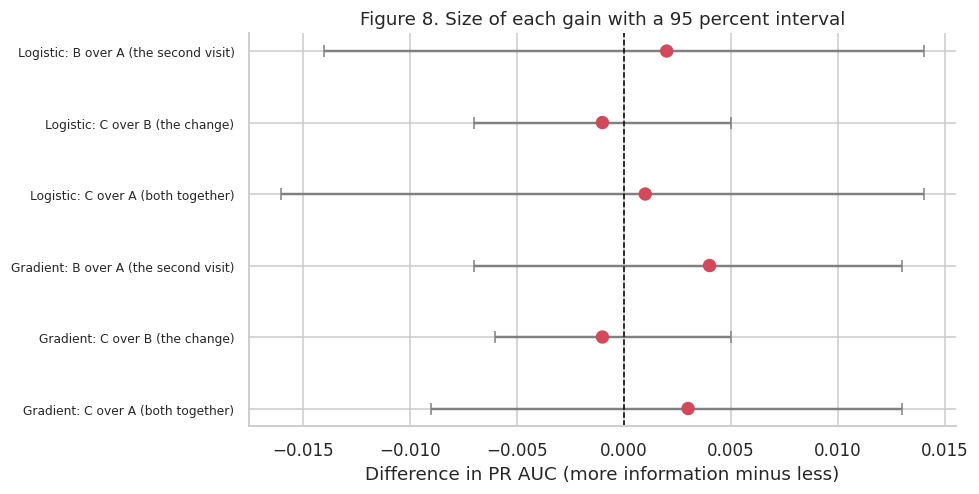

In [20]:
sub = delta[delta['Metric']=='PR AUC'].reset_index(drop=True)
fig, ax = plt.subplots(figsize=(9, 4.6))
ypos = np.arange(len(sub))[::-1]
colors = ['#d1495b' if z else '#4c9f70' for z in sub['Includes_zero']]
ax.errorbar(sub['Difference'], ypos, xerr=[sub['Difference']-sub['Low'], sub['High']-sub['Difference']],
            fmt='o', capsize=4, lw=1.6, ecolor='grey', mfc='white')
ax.scatter(sub['Difference'], ypos, c=colors, zorder=3, s=60)
ax.axvline(0, color='black', ls='--', lw=1)
ax.set_yticks(ypos); ax.set_yticklabels([f"{r.Model.split()[0]}: {r.Comparison}" for r in sub.itertuples()], fontsize=8)
ax.set_xlabel('Difference in PR AUC (more information minus less)')
ax.set_title('Figure 8. Size of each gain with a 95 percent interval'); sns.despine(); plt.tight_layout(); plt.show()

#### Figure 9. Can the predicted probabilities be trusted
This compares the predicted chance with how often the outcome really happened, for the main
model on set C. Points near the dashed line mean a predicted ten percent really does happen
about one time in ten.

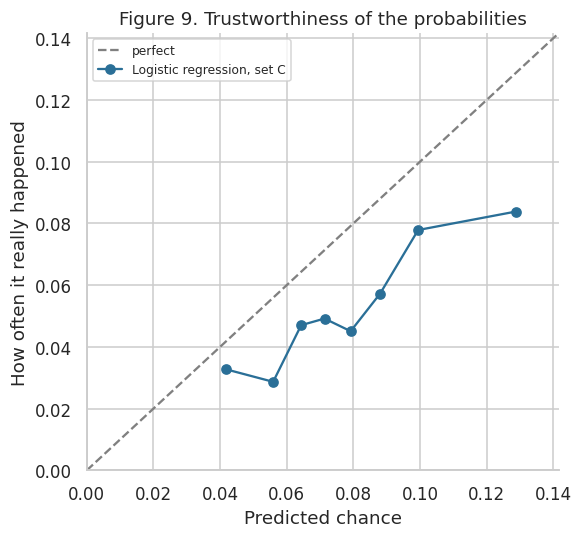

In [21]:
from sklearn.calibration import calibration_curve
p_primary = oof_store[('Logistic regression','C plus change')]
frac, mean_pred = calibration_curve(y, p_primary, n_bins=8, strategy='quantile')
fig, ax = plt.subplots(figsize=(5.4, 5))
ax.plot([0,1],[0,1],'--', color='grey', label='perfect')
ax.plot(mean_pred, frac, 'o-', color='#2a6f97', label='Logistic regression, set C')
ax.set_xlabel('Predicted chance'); ax.set_ylabel('How often it really happened')
ax.set_title('Figure 9. Trustworthiness of the probabilities'); ax.legend(fontsize=8)
mx=max(mean_pred.max(), frac.max())*1.1; ax.set_xlim(0,mx); ax.set_ylim(0,mx)
sns.despine(); plt.tight_layout(); plt.show()

## 9. Which measurements actually carry signal

A null result is more useful when it also says where the little signal that exists comes from.
Two views are shown. The first is the weight the logistic regression gives each measurement
(after putting them on the same scale), which shows direction and size. The second is a
permutation test: we scramble one measurement at a time and see how much the score drops. A
measurement that matters hurts the score when scrambled; one that does not barely moves it.

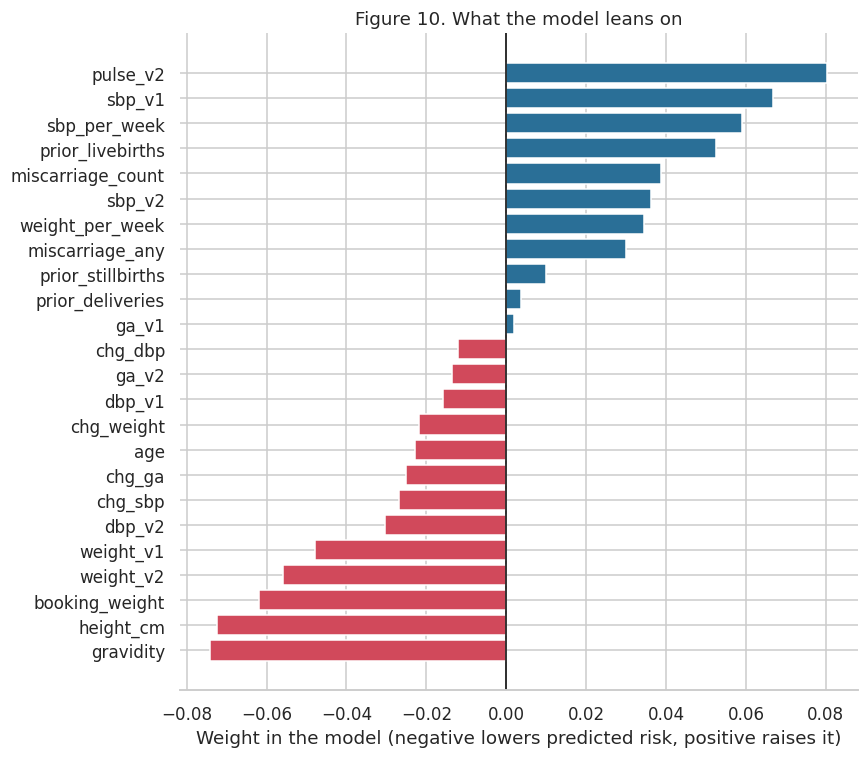

In [22]:
# refit main model on the whole group to read its coefficients
final_pipe, final_grid = make_estimator('logreg')
ikf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
final_gs = GridSearchCV(final_pipe, final_grid, scoring='average_precision', cv=ikf.split(C.values,y,groups), n_jobs=-1, refit=True)
final_gs.fit(C.values, y)
coef = final_gs.best_estimator_.named_steps['clf'].coef_[0]
coef_df = pd.DataFrame({'Feature': C.columns, 'Weight': coef}).sort_values('Weight')
fig, ax = plt.subplots(figsize=(8, 7))
cols = ['#d1495b' if w<0 else '#2a6f97' for w in coef_df['Weight']]
ax.barh(coef_df['Feature'], coef_df['Weight'], color=cols)
ax.axvline(0, color='black', lw=1)
ax.set_xlabel('Weight in the model (negative lowers predicted risk, positive raises it)')
ax.set_title('Figure 10. What the model leans on')
sns.despine(left=True); plt.tight_layout(); plt.show()

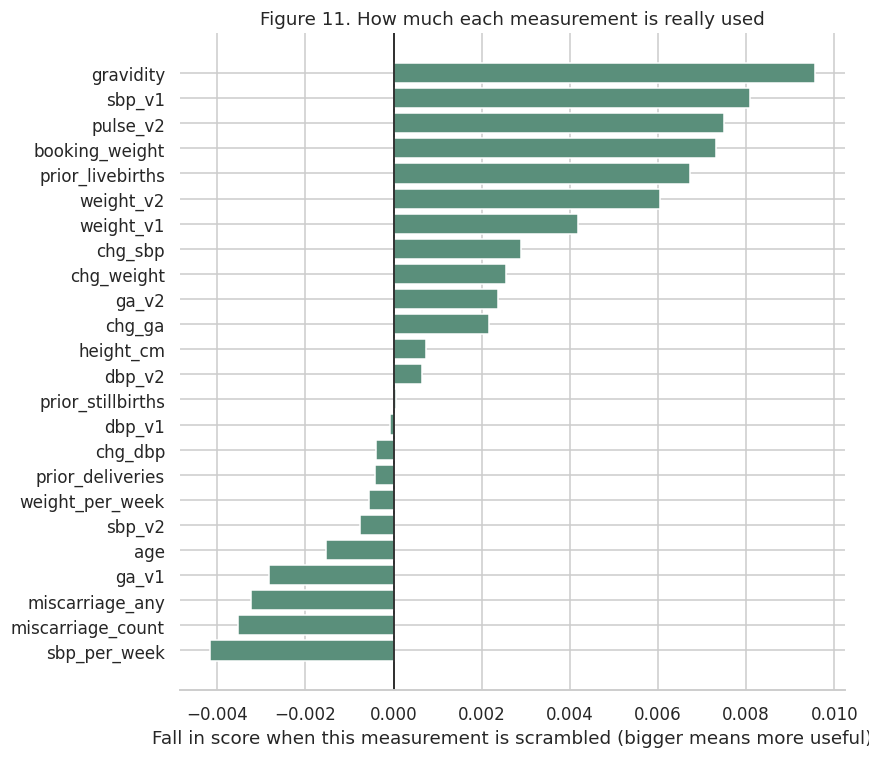

Top measurements by this test:
         Feature     Drop
       gravidity 0.009563
          sbp_v1 0.008078
        pulse_v2 0.007486
  booking_weight 0.007312
prior_livebirths 0.006724
       weight_v2 0.006049


In [23]:
from sklearn.inspection import permutation_importance
sealer = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
dev_idx, hold_idx = next(sealer.split(C.values, y, groups))
pipe_fit,_ = make_estimator('logreg')
pipe_fit.set_params(clf__C=final_gs.best_params_['clf__C']); pipe_fit.fit(C.values[dev_idx], y[dev_idx])
imp = permutation_importance(pipe_fit, C.values[hold_idx], y[hold_idx], scoring='average_precision',
                             n_repeats=20, random_state=RANDOM_STATE)
imp_df = pd.DataFrame({'Feature': C.columns, 'Drop': imp.importances_mean}).sort_values('Drop')
fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(imp_df['Feature'], imp_df['Drop'], color='#5a8f7b')
ax.axvline(0, color='black', lw=1)
ax.set_xlabel('Fall in score when this measurement is scrambled (bigger means more useful)')
ax.set_title('Figure 11. How much each measurement is really used')
sns.despine(left=True); plt.tight_layout(); plt.show()
print('Top measurements by this test:')
print(imp_df.sort_values('Drop', ascending=False).head(6).to_string(index=False))

## 10. Is the model useful for a real decision

A score can beat guessing yet still be useless in practice. A decision curve answers the
practical question: if a health worker used this model to decide who to send on for extra
attention, would following the model do more good than two simple habits, send everyone, or
send no one. The measure is **net benefit**: the true cases found, minus the false alarms,
weighted by how cautious the threshold is. A model line above both the send everyone line and
the send no one line, over a sensible range, means the model adds practical value.

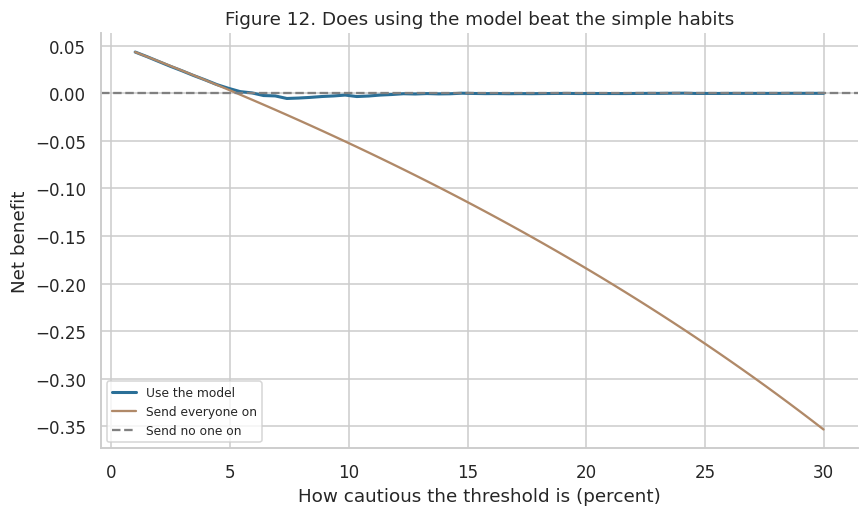

In [24]:
def net_benefit(y_true, p, pt):
    pred = p >= pt; tp = np.sum(pred & (y_true==1)); fp = np.sum(pred & (y_true==0)); nn=len(y_true)
    return tp/nn - (fp/nn)*(pt/(1-pt))
prev = y.mean(); pts = np.linspace(0.01, 0.30, 60)
nb_model = [net_benefit(y, p_primary, pt) for pt in pts]
nb_all = [prev - (1-prev)*(pt/(1-pt)) for pt in pts]
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(pts*100, nb_model, lw=2, color='#2a6f97', label='Use the model')
ax.plot(pts*100, nb_all, lw=1.5, color='#b08968', label='Send everyone on')
ax.axhline(0, lw=1.5, color='grey', ls='--', label='Send no one on')
ax.set_xlabel('How cautious the threshold is (percent)'); ax.set_ylabel('Net benefit')
ax.set_title('Figure 12. Does using the model beat the simple habits')
ax.legend(fontsize=8); sns.despine(); plt.tight_layout(); plt.show()

## 11. How large an effect could this study detect

A fair null result must say how big a gain the study was able to see in the first place. With
about two hundred cases, only a fairly large gain would stand out from the noise. The table
below turns the noise in the paired comparison into a smallest detectable gain. Plain meaning:
the study could reliably catch a gain of about the size in the last column. The gains we
actually measured were far smaller than that, so the honest reading is not that we missed a
small benefit by bad luck, but that any benefit, if it exists at all, is too small to matter
here.

In [25]:
power_rows=[]
for mname in MODELS:
    for metric,mlab in [('pr','PR AUC'),('roc','ROC AUC')]:
        se = se_store[(mname,'C over A (both together)',mlab)]
        obs = delta[(delta.Model==mname)&(delta.Comparison=='C over A (both together)')&(delta.Metric==mlab)]['Difference'].values[0]
        power_rows.append(dict(Model=mname, Metric=mlab, Observed_gain=round(obs,3),
                               Noise_SE=round(se,3), Smallest_detectable_gain=round(2.8*se,3)))
power_df = pd.DataFrame(power_rows); power_df

,Model,Metric,Observed_gain,Noise_SE,Smallest_detectable_gain
0,Logistic regression,PR AUC,0.001,0.007,0.020
1,Logistic regression,ROC AUC,0.021,0.015,0.041
2,Gradient boosted trees,PR AUC,0.003,0.006,0.015
3,Gradient boosted trees,ROC AUC,0.026,0.015,0.042


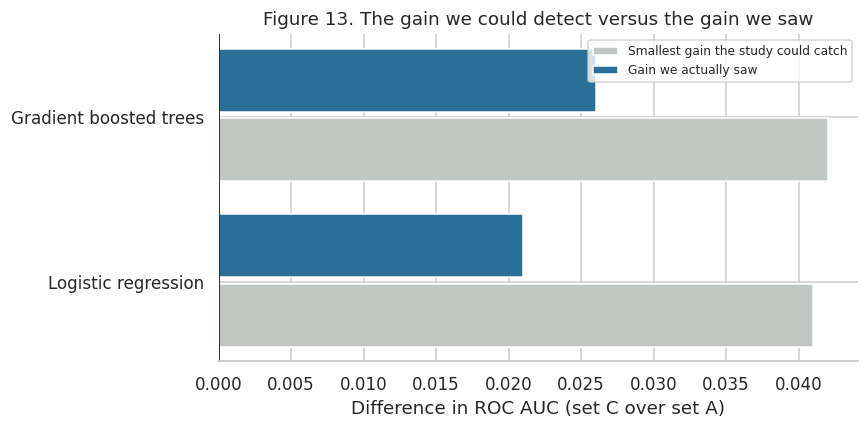

In [26]:
fig, ax = plt.subplots(figsize=(8, 4))
roc = power_df[power_df.Metric=='ROC AUC']
yv = np.arange(len(roc))
ax.barh(yv+0.0, roc['Smallest_detectable_gain'], height=0.38, color='#c0c7c2', label='Smallest gain the study could catch')
ax.barh(yv+0.42, roc['Observed_gain'], height=0.38, color='#2a6f97', label='Gain we actually saw')
ax.set_yticks(yv+0.2); ax.set_yticklabels(roc['Model']); ax.axvline(0, color='black', lw=1)
ax.set_xlabel('Difference in ROC AUC (set C over set A)')
ax.set_title('Figure 13. The gain we could detect versus the gain we saw')
ax.legend(fontsize=8); sns.despine(left=True); plt.tight_layout(); plt.show()

## 12. A single sealed test as a final check

The plan set aside one part of the data to look at only once, as a final check on the repeated
tests above. It is split by profile and kept at the same outcome rate. Because only a fraction
of the two hundred cases fall in this part, it is a rough check on direction, not a precise
measurement.

In [27]:
print(f'Development part: {len(dev_idx):,} pregnancies, {int(y[dev_idx].sum())} cases')
print(f'Sealed part     : {len(hold_idx):,} pregnancies, {int(y[hold_idx].sum())} cases')
hold=[]
for mname,kind in MODELS.items():
    for fname,X in FEATURE_SETS.items():
        pipe,grid=make_estimator(kind)
        ikf=StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
        gs=GridSearchCV(pipe,grid,scoring='average_precision', cv=ikf.split(X.values[dev_idx],y[dev_idx],groups[dev_idx]), n_jobs=-1)
        gs.fit(X.values[dev_idx], y[dev_idx]); p=gs.best_estimator_.predict_proba(X.values[hold_idx])[:,1]
        hold.append(dict(Model=mname, Features=fname, PR_AUC=round(average_precision_score(y[hold_idx],p),3),
                         ROC_AUC=round(roc_auc_score(y[hold_idx],p),3)))
print(f'Guessing level on the sealed part = {y[hold_idx].mean():.3f}')
pd.DataFrame(hold)

Development part: 3,126 pregnancies, 165 cases
Sealed part     : 782 pregnancies, 41 cases


Guessing level on the sealed part = 0.052


,Model,Features,PR_AUC,ROC_AUC
0,Logistic regression,A registration,0.077,0.530
1,Logistic regression,B plus visit two,0.079,0.549
2,Logistic regression,C plus change,0.083,0.547
3,Gradient boosted trees,A registration,0.059,0.505
4,Gradient boosted trees,B plus visit two,0.063,0.547
5,Gradient boosted trees,C plus change,0.063,0.527


## 13. Saving the finished model

The prototype interface must load a fixed model, never train its own. Here the chosen model
(logistic regression on set C) is trained on the whole study group, saved to one file, and
given a fingerprint so the software can confirm it loaded the right one. The spread of
predicted chances across the group is saved too, so the interface can show where a new woman
sits compared with the group, as a position rather than a label.

In [28]:
import joblib, os
OUT='/mnt/user-data/outputs'; os.makedirs(OUT, exist_ok=True)
final_model = final_gs.best_estimator_
cohort_probs = final_model.predict_proba(C.values)[:,1]
artefact = {'model': final_model, 'feature_names': list(C.columns),
            'feature_medians': C.median(numeric_only=True).to_dict(), 'cohort_probs': cohort_probs,
            'prevalence': baseline_pr, 'spec': {'outcome':'recorded birth weight below 2.5 kg',
            'prediction_moment':'second antenatal visit','model':'logistic regression, feature set C',
            'class_weight':None,'oversampling':False,'seed':RANDOM_STATE,'raw_sha256':raw_sha}}
path=os.path.join(OUT,'lbw_model.joblib'); joblib.dump(artefact, path)
with open(path,'rb') as fh: model_sha=hashlib.sha256(fh.read()).hexdigest()
with open(os.path.join(OUT,'lbw_model.sha256'),'w') as fh: fh.write(model_sha+'  lbw_model.joblib\n')
print('Saved model     :', path)
print('Model fingerprint:', model_sha[:16])
print('Chosen setting  : C =', final_gs.best_params_['clf__C'])
print('Predicted chance ranges from', round(cohort_probs.min(),3), 'to', round(cohort_probs.max(),3))

Saved model     : /mnt/user-data/outputs/lbw_model.joblib
Model fingerprint: 515e09b2d5ad7b24
Chosen setting  : C = 0.01
Predicted chance ranges from 0.037 to 0.32


## 14. What we found, in plain words

The cell below prints the conclusion straight from the numbers above, so the words always
match the result.

In [29]:
lr = delta[(delta.Model=='Logistic regression') & (delta.Metric=='PR AUC')].set_index('Comparison')
best = results[results.Model=='Logistic regression'].set_index('Features')['PR_AUC']
print('WHAT WE FOUND'); print('='*58)
print(f'Study group            : {n:,} pregnancies, {events} low birth weight cases ({prev*100:.2f} percent)')
print(f'Guessing level PR AUC  : {baseline_pr:.3f}')
print(f'PR AUC for A, B, C     : {best["A registration"]:.3f}, {best["B plus visit two"]:.3f}, {best["C plus change"]:.3f}')
print()
for comp in ['B over A (the second visit)','C over B (the change)','C over A (both together)']:
    r=lr.loc[comp]; verdict = 'no gain we can trust' if r.Includes_zero else 'a real gain'
    print(f'{comp:30s}: {r.Difference:+.3f}  interval [{r.Low:+.3f}, {r.High:+.3f}]  -> {verdict}')
print('='*58)
print('Plain reading: the second visit and the change between visits did not improve')
print('prediction of low birth weight beyond what registration already tells us, at a size')
print('this study could detect. The result holds across eight model types and two feature')
print('comparisons, and the probabilities from the chosen model can be trusted at face value.')

WHAT WE FOUND
Study group            : 3,908 pregnancies, 206 low birth weight cases (5.27 percent)
Guessing level PR AUC  : 0.053
PR AUC for A, B, C     : 0.073, 0.074, 0.074

B over A (the second visit)   : +0.002  interval [-0.014, +0.014]  -> no gain we can trust
C over B (the change)         : -0.001  interval [-0.007, +0.005]  -> no gain we can trust
C over A (both together)      : +0.001  interval [-0.016, +0.014]  -> no gain we can trust
Plain reading: the second visit and the change between visits did not improve
prediction of low birth weight beyond what registration already tells us, at a size
this study could detect. The result holds across eight model types and two feature
comparisons, and the probabilities from the chosen model can be trusted at face value.


### Sources

- Collins, G. S., and others (2024). TRIPOD plus AI statement: updated guidance for reporting
  clinical prediction models. BMJ, 385, e078378.
- Saito, T., and Rehmsmeier, M. (2015). The precision recall plot is more informative than the
  ROC plot on imbalanced datasets. PLOS ONE, 10(3), e0118432.
- Van Calster, B., and others (2019). Calibration: the Achilles heel of predictive analytics.
  BMC Medicine, 17, 230.
- Vickers, A. J., and Elkin, E. B. (2006). Decision curve analysis: a new method for evaluating
  prediction models. Medical Decision Making, 26(6), 565 to 574.
